Import neccessary libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.set_printoptions(precision=4, suppress=True)

🔹 Section 1: Simulate Synthetic Point Correspondences

    Definition:
      # Generate minimal set of point correspondences between two views.

    Importance:
      # Required for 7-point fundamental matrix estimation (minimum solution).

In [2]:
# Generate random 3D points
np.random.seed(42)
N = 8  # More than 7 for better linear fit
X = np.random.rand(3, N) * 2 + np.array([[0], [0], [4]])  # Depth range [4,6]
X_h = np.vstack((X, np.ones((1, N))))  # homogeneous

# Camera intrinsics
K = np.array([
    [800, 0, 320],
    [0, 800, 240],
    [0, 0, 1]
])

# Left camera: identity
P1 = K @ np.hstack((np.eye(3), np.zeros((3, 1))))

# Right camera: translate and rotate slightly
theta = np.radians(10)
R = np.array([
    [np.cos(theta), 0, np.sin(theta)],
    [0, 1, 0],
    [-np.sin(theta), 0, np.cos(theta)]
])
t = np.array([[0.5], [0.1], [0.0]])
P2 = K @ np.hstack((R, t))

# Project points
x1 = P1 @ X_h
x2 = P2 @ X_h
x1 /= x1[2]
x2 /= x2[2]

# Normalize image coordinates (for fundamental estimation)
x1n = np.linalg.inv(K) @ x1
x2n = np.linalg.inv(K) @ x2

🔹 Section 2: Parametric Representation of F

    Definition:
        # F is a 3x3 matrix of rank 2, up to scale.
        # 7-point algorithm solves for F from det(F) = 0 constraint.




In [3]:
# Construct matrix A from 8 correspondences (x2.T @ F @ x1 = 0)
A = []
for i in range(N):
    X1 = x1n[:, i]
    X2 = x2n[:, i]
    A.append([
        X2[0]*X1[0], X2[0]*X1[1], X2[0],
        X2[1]*X1[0], X2[1]*X1[1], X2[1],
        X1[0], X1[1], 1
    ])
A = np.array(A)

# Solve Af = 0 using SVD
U, S, Vt = np.linalg.svd(A)
F1 = Vt[-1].reshape(3, 3)
F2 = Vt[-2].reshape(3, 3)

🔹 Section 3: Enforce Singularity Constraint (det(F) = 0)

    Definition:
        # Fundamental matrix must be rank 2 (its determinant = 0)

In [4]:
def enforce_singularity(F):
    U, S, Vt = np.linalg.svd(F)
    S[-1] = 0  # set smallest singular value to 0
    return U @ np.diag(S) @ Vt

# Interpolate F = aF1 + (1-a)F2 to satisfy det(F) = 0
alphas = np.linspace(0, 1, 100)
best_F = None
for a in alphas:
    F = a * F1 + (1 - a) * F2
    if abs(np.linalg.det(F)) < 1e-6:
        best_F = enforce_singularity(F)
        break

print("Estimated Fundamental Matrix (F):\n", best_F)

Estimated Fundamental Matrix (F):
 [[ 0.0241  0.     -0.1366]
 [-0.1204 -0.      0.6828]
 [ 0.1366 -0.6934  0.0241]]


🔹 Section 4: Compute Essential Matrix

    Formula: E = Kᵗ * F * K

    Importance: Contains only rotation and translation; used for camera recovery

In [5]:
E = K.T @ best_F @ K
print("\nEssential Matrix (E):\n", E)


Essential Matrix (E):
 [[ 15411.6285      0.       6055.3968]
 [-77058.1426     -0.     -30276.984 ]
 [-16843.5368   -554.7002  -6783.6206]]


🔹 Section 5: Decompose Essential Matrix into R, t

    Definition:
        E = [t]_x R; Four possible decompositions

In [6]:
def decompose_E(E):
    U, S, Vt = np.linalg.svd(E)
    if np.linalg.det(U) < 0: U *= -1
    if np.linalg.det(Vt) < 0: Vt *= -1

    W = np.array([
        [0, -1, 0],
        [1, 0, 0],
        [0, 0, 1]
    ])

    R1 = U @ W @ Vt
    R2 = U @ W.T @ Vt
    t = U[:, 2]

    return (R1, t), (R1, -t), (R2, t), (R2, -t)

candidates = decompose_E(E)

🔹 Section 6: Linear Triangulation & Selecting Correct Pose

    Importance:
      # Choose (R, t) that gives positive depth for all points (cheirality constraint)

In [7]:
def triangulate(P1, P2, pts1, pts2):
    X = []
    for i in range(pts1.shape[1]):
        x1, x2 = pts1[:, i], pts2[:, i]
        A = np.array([
            x1[0]*P1[2] - P1[0],
            x1[1]*P1[2] - P1[1],
            x2[0]*P2[2] - P2[0],
            x2[1]*P2[2] - P2[1],
        ])
        _, _, Vt = np.linalg.svd(A)
        X_h = Vt[-1]
        X.append(X_h[:3] / X_h[3])
    return np.array(X).T

def positive_depth(P, X):
    X_h = np.vstack((X, np.ones((1, X.shape[1]))))
    x_cam = P @ X_h
    return np.all(x_cam[2] > 0)

best_X, best_pose = None, None
for R, t in candidates:
    P2_test = K @ np.hstack((R, t.reshape(3, 1)))
    X_test = triangulate(P1, P2_test, x1, x2)
    if positive_depth(P2_test, X_test):
        best_X = X_test
        best_pose = (R, t)
        break

🔹 Section 7: Reprojection Error Minimization

    Definition:
      # Project 3D points back to both images and compare with observed 2D points.

    Importance:
      # Lower error = more accurate reconstruction

In [8]:
X_h = np.vstack((best_X, np.ones((1, best_X.shape[1]))))
x1_proj = P1 @ X_h
x2_proj = K @ np.hstack((best_pose[0], best_pose[1].reshape(3, 1))) @ X_h
x1_proj /= x1_proj[2]
x2_proj /= x2_proj[2]

err1 = np.linalg.norm(x1[:2] - x1_proj[:2], axis=0).mean()
err2 = np.linalg.norm(x2[:2] - x2_proj[:2], axis=0).mean()
print(f"\nReprojection Error Left: {err1:.4f} pixels")
print(f"Reprojection Error Right: {err2:.4f} pixels")


Reprojection Error Left: 245.6870 pixels
Reprojection Error Right: 578.9588 pixels


🔹 Section 8: Plot 3D Structure from Triangulation

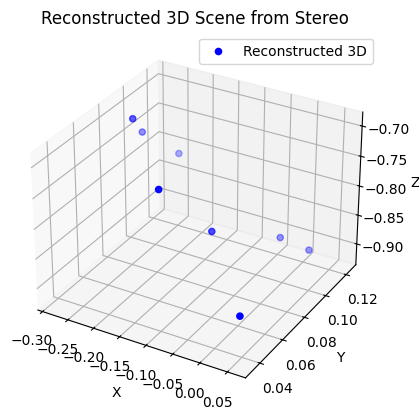

In [9]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(*best_X, c='blue', label="Reconstructed 3D")
ax.set_title("Reconstructed 3D Scene from Stereo")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
plt.show()

🔹 Section 9: Affine Epipolar Geometry & Homography Compatible Stereo

    Definition:
        # If scene is planar or camera motion is affine-like, F can be approximated.

    Importance:
        # Useful in structure-from-motion & homography-based stereo.

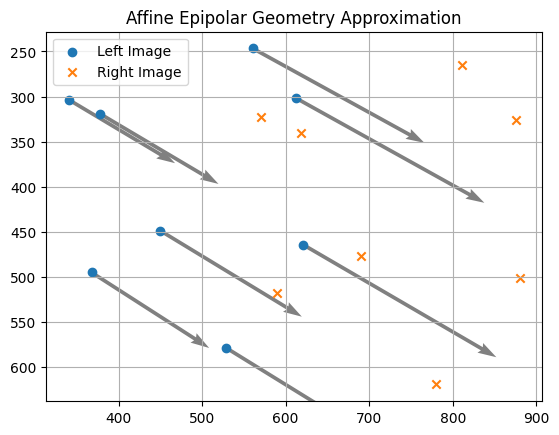

In [10]:
# Approximate affine F using linear model: drop Z-dependence
x1_affine = x1[:2]
x2_affine = x2[:2]

# Estimate affine fundamental (just affine transform between planes)
A_affine = np.linalg.lstsq(x1_affine.T, x2_affine.T, rcond=None)[0]
x2_est = A_affine @ x1_affine

plt.figure()
plt.quiver(x1_affine[0], x1_affine[1], x2_est[0]-x1_affine[0], x2_est[1]-x1_affine[1],
           angles='xy', scale_units='xy', scale=1, color='gray')
plt.scatter(*x1_affine, label='Left Image')
plt.scatter(*x2_affine, label='Right Image', marker='x')
plt.title("Affine Epipolar Geometry Approximation")
plt.legend()
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()